In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")

print("Path to dataset files:", path)

100%|██████████| 16.1M/16.1M [00:00<00:00, 75.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shivamb/real-or-fake-fake-jobposting-prediction/versions/1


In [ ]:
import pandas as pd
import os

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'fake_job_postings.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


### Class Balance Analysis of 'fraudulent' Column
Let's examine the distribution of the 'fraudulent' column to understand the class balance. This is important for classification tasks, as imbalanced datasets can lead to models that perform poorly on minority classes.

In [ ]:
# Calculate the value counts for the 'fraudulent' column
class_distribution = df['fraudulent'].value_counts()

# Display the class distribution
print("Class distribution of 'fraudulent' column:")
display(class_distribution)

# Calculate and display the percentage distribution
class_percentage = df['fraudulent'].value_counts(normalize=True) * 100
print("\nClass percentage distribution:")
display(class_percentage)

Class distribution of 'fraudulent' column:


,count
fraudulent,
0,17014
1,866



Class percentage distribution:


,proportion
fraudulent,
0,95.1566
1,4.8434


/tmp/ipykernel_2574/3866799362.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')


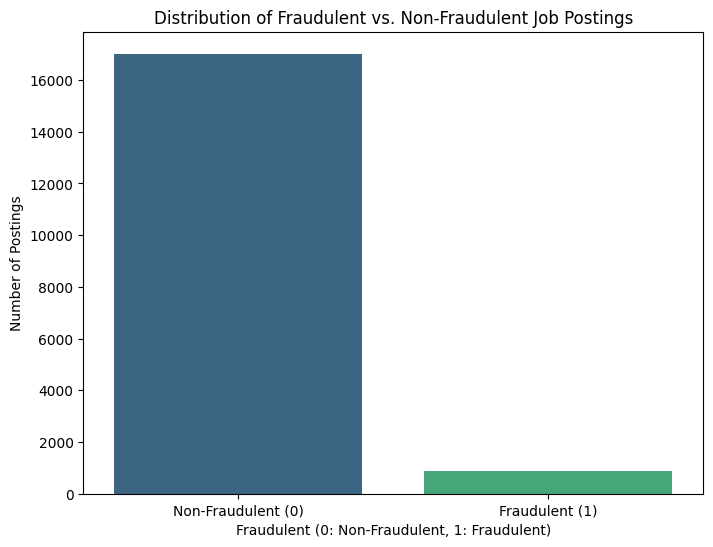

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Job Postings')
plt.xlabel('Fraudulent (0: Non-Fraudulent, 1: Fraudulent)')
plt.ylabel('Number of Postings')
plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent (0)', 'Fraudulent (1)'])
plt.show()

### Exploring Correlations with 'fraudulent' Column
Let's examine how other features correlate with the `fraudulent` column. We'll start with numerical/boolean features and then look into categorical ones.

Correlation of numerical/boolean features with 'fraudulent':


,fraudulent
telecommuting,0.034523
has_company_logo,-0.261971
has_questions,-0.091627


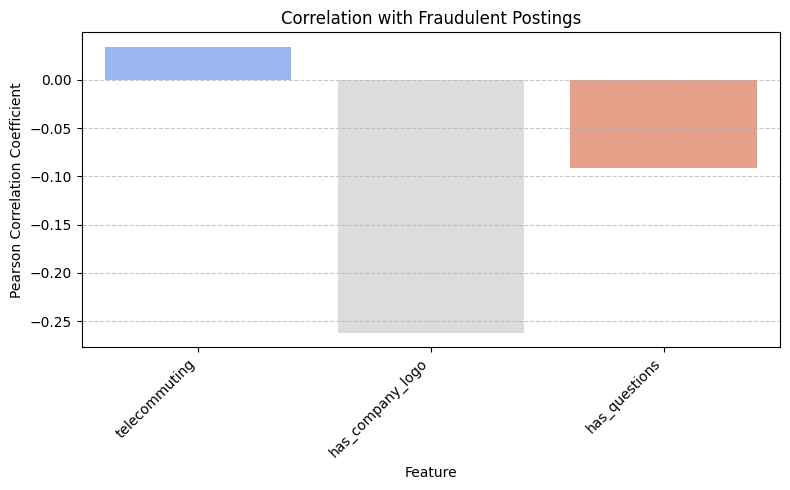

In [ ]:
import numpy as np

# Select numerical and boolean-like columns for correlation
correlation_cols = ['telecommuting', 'has_company_logo', 'has_questions']

# Calculate Pearson correlation with the 'fraudulent' column
correlations = df[correlation_cols + ['fraudulent']].corr()['fraudulent'][:-1]

print("Correlation of numerical/boolean features with 'fraudulent':")
display(correlations)

# Visualize these correlations
plt.figure(figsize=(8, 5))
sns.barplot(x=correlations.index, y=correlations.values, hue=correlations.index, palette='coolwarm', legend=False)
plt.title('Correlation with Fraudulent Postings')
plt.xlabel('Feature')
plt.ylabel('Pearson Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The correlation analysis shows that `has_company_logo` and `has_questions` have negative correlations with 'fraudulent', meaning fraudulent job postings are less likely to have a company logo or questions. `telecommuting` has a very slight positive correlation, indicating that telecommuting jobs might be marginally more prone to being fraudulent.

Now, let's explore some key categorical features to see their relationship with fraudulent postings.

### Text Preprocessing for 'description' and 'requirements' Columns
To prepare the text data for natural language processing, we will perform several preprocessing steps. This includes handling missing values, combining relevant text columns, cleaning the text, and then applying tokenization, stop word removal, and lemmatization.

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from bs4 import BeautifulSoup

# Download necessary NLTK data (if not already downloaded)
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


#### 1. Handle Missing Values and Combine Text Columns
First, we'll fill any missing values in 'description' and 'requirements' with empty strings to avoid errors. Then, we'll combine these into a new 'text_combined' column, as both contain important information about the job.

In [ ]:
# Fill NaN values in text columns with empty strings
df['description'] = df['description'].fillna('')
df['requirements'] = df['requirements'].fillna('')

# Combine 'description' and 'requirements' into a new 'text_combined' column
df['text_combined'] = df['description'] + ' ' + df['requirements']

#### 2. Basic Text Cleaning Function
This function will perform the following steps:
- Remove HTML tags.
- Convert text to lowercase.
- Remove non-alphabetic characters (punctuation, numbers, special symbols).
- Remove extra whitespace.

In [ ]:
def clean_text(text):
    # Remove HTML tags
    text = BeautifulSoup(text, 'html.parser').get_text()
    # Convert to lowercase
    text = text.lower()
    # Remove non-alphabetic characters (keeping spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply the cleaning function to the combined text
df['cleaned_text'] = df['text_combined'].apply(clean_text)

display(df[['text_combined', 'cleaned_text']].head())

,text_combined,cleaned_text
0,"Food52, a fast-growing, James Beard Award-winn...",food a fastgrowing james beard awardwinning on...
1,Organised - Focused - Vibrant - Awesome!Do you...,organised focused vibrant awesomedo you have a...
2,"Our client, located in Houston, is actively se...",our client located in houston is actively seek...
3,THE COMPANY: ESRI – Environmental Systems Rese...,the company esri environmental systems researc...
4,JOB TITLE: Itemization Review ManagerLOCATION:...,job title itemization review managerlocation f...


#### 3. Tokenization, Stop Word Removal, and Lemmatization Function
This function will further process the cleaned text by:
- Tokenizing the text into individual words.
- Removing common English stop words.
- Lemmatizing words to their base form.

In [ ]:
def process_text(text):
    # Tokenize the text
    tokens = text.split()
    # Remove stop words and lemmatize
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(processed_tokens)

# Apply the processing function to the cleaned text
df['processed_text'] = df['cleaned_text'].apply(process_text)

display(df[['cleaned_text', 'processed_text']].head())

,cleaned_text,processed_text
0,food a fastgrowing james beard awardwinning on...,food fastgrowing james beard awardwinning onli...
1,organised focused vibrant awesomedo you have a...,organised focused vibrant awesomedo passion cu...
2,our client located in houston is actively seek...,client located houston actively seeking experi...
3,the company esri environmental systems researc...,company esri environmental system research ins...
4,job title itemization review managerlocation f...,job title itemization review managerlocation f...


#### 4. Word Cloud for Fraudulent Postings
Let's visualize the most frequent words in fraudulent job postings to get a quick overview of their common themes and vocabulary.

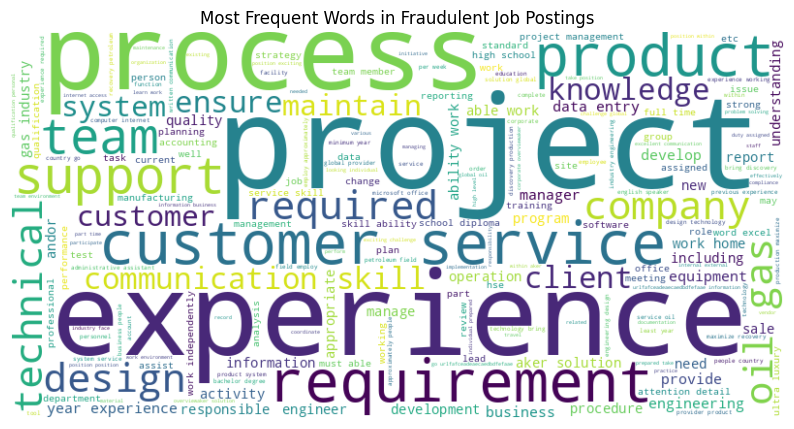

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter for fraudulent job postings
fraudulent_df = df[df['fraudulent'] == 1]

# Combine all processed text from fraudulent postings into a single string
all_fraudulent_text = ' '.join(fraudulent_df['processed_text'])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_fraudulent_text)

# Display the word cloud
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Fraudulent Job Postings')
plt.show()

#### 5. Word Cloud for Legitimate Postings
Now, let's visualize the most frequent words in *legitimate* job postings to compare them with the fraudulent ones. This can help identify distinctive language patterns.

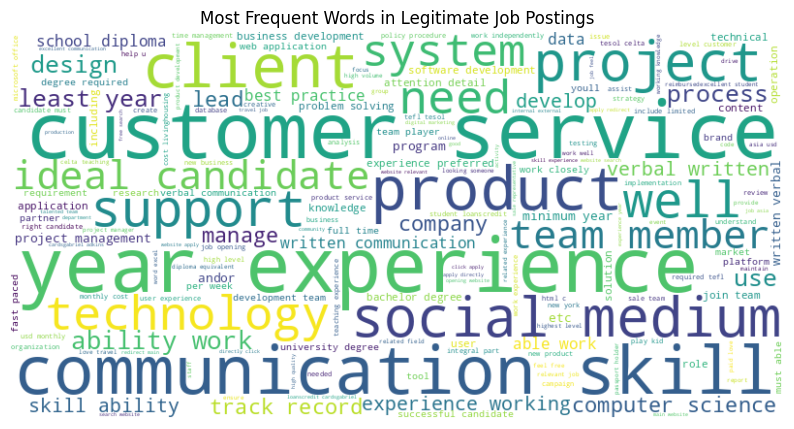

In [ ]:
# Filter for legitimate (non-fraudulent) job postings
legitimate_df = df[df['fraudulent'] == 0]

# Combine all processed text from legitimate postings into a single string
all_legitimate_text = ' '.join(legitimate_df['processed_text'])

# Generate a word cloud for legitimate postings
wordcloud_legitimate = WordCloud(width=800, height=400, background_color='white').generate(all_legitimate_text)

# Display the word cloud
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_legitimate, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Legitimate Job Postings')
plt.show()

### Análisis de Sentimiento del Texto Procesado
Ahora, vamos a realizar un análisis de sentimiento en el texto de las descripciones de los trabajos para ver si hay diferencias notables en la polaridad entre los anuncios fraudulentos y legítimos. Utilizaremos `TextBlob` para una rápida aproximación a la polaridad del sentimiento.

In [ ]:
# Instalar la librería TextBlob si aún no está instalada
!pip install textblob

In [ ]:
from textblob import TextBlob

# Función para obtener la polaridad del sentimiento
def get_sentiment_polarity(text):
    return TextBlob(text).sentiment.polarity

# Aplicar la función a la columna 'processed_text'
df['sentiment_polarity'] = df['processed_text'].apply(get_sentiment_polarity)

# Mostrar las primeras filas con la nueva columna de polaridad
display(df[['processed_text', 'sentiment_polarity', 'fraudulent']].head())

,processed_text,sentiment_polarity,fraudulent
0,food fastgrowing james beard awardwinning onli...,0.035480,0
1,organised focused vibrant awesomedo passion cu...,0.258690,0
2,client located houston actively seeking experi...,0.337037,0
3,company esri environmental system research ins...,0.228762,0
4,job title itemization review managerlocation f...,0.142898,0


### Comparación de la Polaridad del Sentimiento entre Anuncios Fraudulentos y Legítimos
Vamos a comparar la polaridad media del sentimiento para los anuncios fraudulentos y los legítimos para ver si hay un patrón distintivo.

### Test Estadístico de la Diferencia de Medias de Polaridad del Sentimiento

Para determinar si la diferencia observada en la polaridad media del sentimiento entre los anuncios fraudulentos y legítimos es estadísticamente significativa, realizaremos un t-test de Student para muestras independientes. Este test nos ayudará a evaluar la probabilidad de que estas dos medias provengan de la misma población (es decir, que no haya una diferencia real).

In [ ]:
from scipy import stats

# Separar la polaridad del sentimiento para anuncios fraudulentos y legítimos
sentiment_fraudulent = df[df['fraudulent'] == 1]['sentiment_polarity'].dropna()
sentiment_legitimate = df[df['fraudulent'] == 0]['sentiment_polarity'].dropna()

# Realizar un t-test para muestras independientes
# Se asume varianzas desiguales (Walch's t-test) debido a la posible diferencia en el tamaño de las muestras y la naturaleza de los datos.
t_stat, p_value = stats.ttest_ind(sentiment_legitimate, sentiment_fraudulent, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretar el resultado
alpha = 0.05 # Nivel de significancia

if p_value < alpha:
    print(f"\nDado que el p-value ({p_value:.4f}) es menor que el nivel de significancia ({alpha}), rechazamos la hipótesis nula.")
    print("Concluimos que hay una diferencia estadísticamente significativa en la polaridad media del sentimiento entre los anuncios legítimos y fraudulentos.")
else:
    print(f"\nDado que el p-value ({p_value:.4f}) es mayor que el nivel de significancia ({alpha}), no rechazamos la hipótesis nula.")
    print("Concluimos que no hay una diferencia estadísticamente significativa en la polaridad media del sentimiento entre los anuncios legítimos y fraudulentos.")

T-statistic: 3.3913
P-value: 0.0007

Dado que el p-value (0.0007) es menor que el nivel de significancia (0.05), rechazamos la hipótesis nula.
Concluimos que hay una diferencia estadísticamente significativa en la polaridad media del sentimiento entre los anuncios legítimos y fraudulentos.


Polaridad media del sentimiento:


,sentiment_polarity
fraudulent,
0,0.204471
1,0.190892


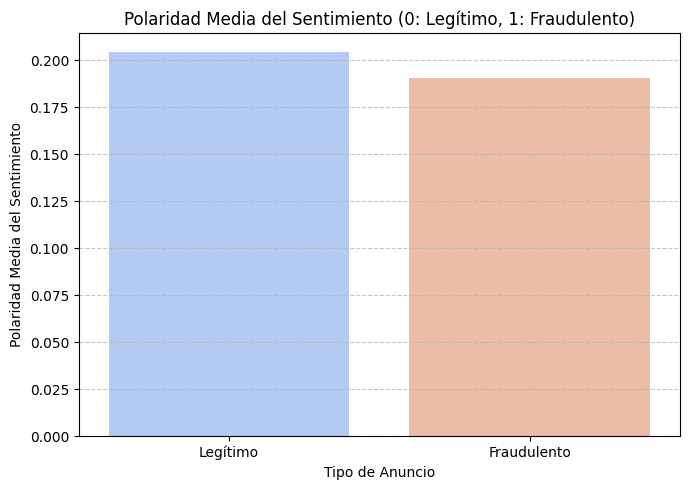

In [ ]:
# Calcular la polaridad media del sentimiento para anuncios fraudulentos y legítimos
sentiment_comparison = df.groupby('fraudulent')['sentiment_polarity'].mean()

print("Polaridad media del sentimiento:")
display(sentiment_comparison)

# Visualizar la comparación
plt.figure(figsize=(7, 5))
sns.barplot(x=sentiment_comparison.index, y=sentiment_comparison.values, hue=sentiment_comparison.index, palette='coolwarm', legend=False)
plt.title('Polaridad Media del Sentimiento (0: Legítimo, 1: Fraudulento)')
plt.xlabel('Tipo de Anuncio')
plt.ylabel('Polaridad Media del Sentimiento')
plt.xticks(ticks=[0, 1], labels=['Legítimo', 'Fraudulento'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Desviación estándar de la polaridad del sentimiento:


,sentiment_polarity
fraudulent,
0,0.120043
1,0.114677


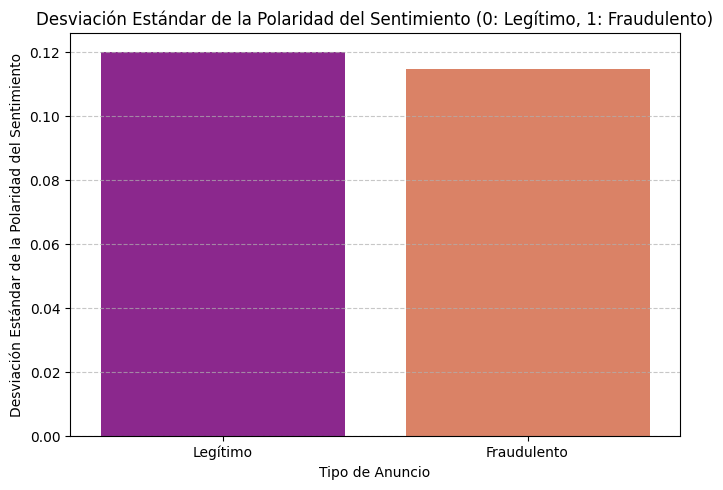

In [ ]:
# Calcular la desviación estándar de la polaridad del sentimiento para anuncios fraudulentos y legítimos
sentiment_std_dev = df.groupby('fraudulent')['sentiment_polarity'].std()

print("Desviación estándar de la polaridad del sentimiento:")
display(sentiment_std_dev)

# Visualizar la comparación de la desviación estándar
plt.figure(figsize=(7, 5))
sns.barplot(x=sentiment_std_dev.index, y=sentiment_std_dev.values, hue=sentiment_std_dev.index, palette='plasma', legend=False)
plt.title('Desviación Estándar de la Polaridad del Sentimiento (0: Legítimo, 1: Fraudulento)')
plt.xlabel('Tipo de Anuncio')
plt.ylabel('Desviación Estándar de la Polaridad del Sentimiento')
plt.xticks(ticks=[0, 1], labels=['Legítimo', 'Fraudulento'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Distribución de la Polaridad del Sentimiento

Para obtener una comprensión más profunda de la polaridad del sentimiento, visualizaremos su distribución mediante un histograma comparativo para anuncios legítimos y fraudulentos. Esto nos permitirá observar si hay diferencias en la forma de la distribución, el rango de valores, o la concentración de sentimientos en cada categoría.

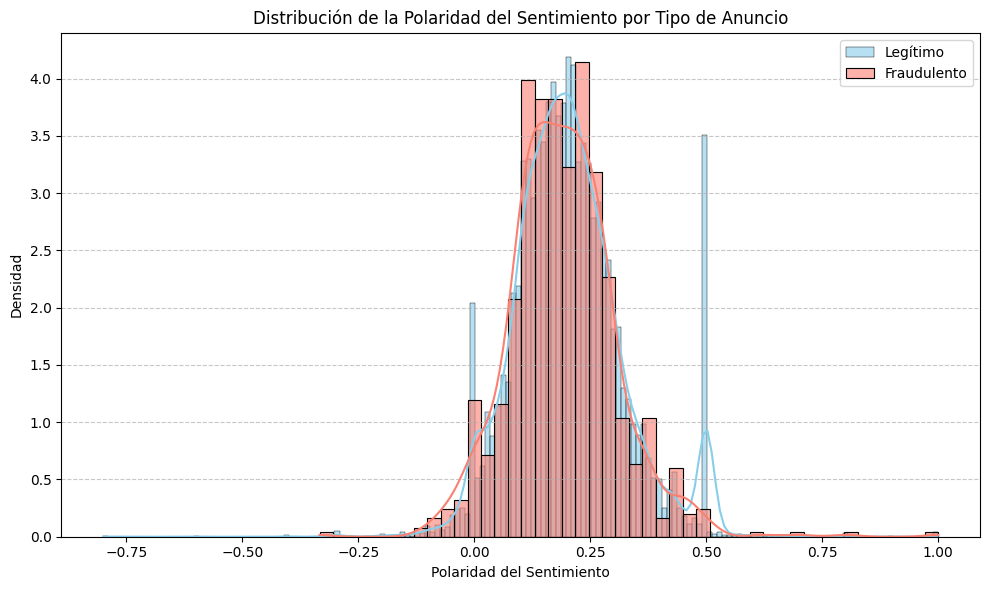

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['fraudulent'] == 0]['sentiment_polarity'], color='skyblue', label='Legítimo', kde=True, stat='density', alpha=0.6)
sns.histplot(df[df['fraudulent'] == 1]['sentiment_polarity'], color='salmon', label='Fraudulento', kde=True, stat='density', alpha=0.6)
plt.title('Distribución de la Polaridad del Sentimiento por Tipo de Anuncio')
plt.xlabel('Polaridad del Sentimiento')
plt.ylabel('Densidad')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análisis de Tópicos con LDA (Latent Dirichlet Allocation)

Para descubrir patrones y temas subyacentes en el texto de las descripciones de empleo, utilizaremos el modelado de tópicos con LDA. Esto nos permitirá ver qué conjuntos de palabras tienden a aparecer juntas y formar "tópicos".

In [ ]:
!pip install gensim
import gensim
import gensim.corpora as corpora

# Preparar los datos tokenizando el texto procesado
data_words = df['processed_text'].apply(lambda x: x.split())

# Crear un diccionario
id2word = corpora.Dictionary(data_words)

# Filtrar palabras muy raras o muy comunes
id2word.filter_extremes(no_below=5, no_above=0.5)

# Crear el corpus (Bag of Words)
corpus = [id2word.doc2bow(text) for text in data_words]

print("Número de palabras únicas en el diccionario:", len(id2word))
print("Primeros 5 documentos del corpus (BoW):")
print(corpus[:5])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.9 MB/s eta 0:00:00
Número de palabras únicas en el diccionario: 20427
Primeros 5 documentos del corpus (BoW):
[[(0, 2), (1, 4), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 2), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 3), (21, 2), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 2), (30, 1), (31, 1), (32, 1), (33, 2), (34, 1), (35, 1), (36, 1), (37, 1), (38, 2), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 7), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 2), (66, 1), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 1), (73, 1), (74, 1), (75, 1), (76, 1), (77, 1), (78, 1), (79, 1), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 1), (87, 1), (88, 1), (89, 1), (90, 1), (91, 1), (92, 1), (

#### Entrenamiento del Modelo LDA

Ahora entrenaremos el modelo LDA. Elegiremos un número de tópicos (por ejemplo, 5) y veremos qué palabras clave definen cada uno.

In [ ]:
# Número de tópicos que queremos identificar
num_topics = 5

# Construir el modelo LDA
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=num_topics,
    random_state=100, # Para reproducibilidad
    update_every=1, # Frecuencia de actualización de los parámetros del modelo
    chunksize=100, # Número de documentos a procesar a la vez
    passes=10, # Número de pasadas por el corpus
    alpha='auto', # Parámetro alpha para el modelo
    per_word_topics=True # Para obtener la distribución de tópicos por palabra
)

# Imprimir los tópicos
print("\nLos tópicos identificados y sus palabras clave principales son:")
for idx, topic in lda_model.print_topics():
    print(f"Topic: {idx}\nWords: {topic}")


Los tópicos identificados y sus palabras clave principales son:
Topic: 0
Words: 0.010*"looking" + 0.008*"product" + 0.008*"marketing" + 0.008*"new" + 0.007*"customer" + 0.007*"company" + 0.006*"working" + 0.006*"people" + 0.006*"business" + 0.006*"design"
Topic: 1
Words: 0.013*"project" + 0.012*"management" + 0.010*"development" + 0.010*"system" + 0.010*"data" + 0.008*"client" + 0.008*"business" + 0.007*"technical" + 0.007*"software" + 0.007*"knowledge"
Topic: 2
Words: 0.023*"customer" + 0.015*"mail" + 0.012*"document" + 0.010*"cnc" + 0.010*"scanning" + 0.010*"email" + 0.009*"onlyclick" + 0.009*"required" + 0.008*"service" + 0.008*"item"
Topic: 3
Words: 0.077*"sale" + 0.025*"customer" + 0.024*"closing" + 0.019*"job" + 0.018*"website" + 0.015*"business" + 0.014*"apply" + 0.014*"search" + 0.011*"market" + 0.010*"relationship"
Topic: 4
Words: 0.024*"service" + 0.015*"customer" + 0.011*"position" + 0.010*"must" + 0.008*"ability" + 0.007*"able" + 0.007*"title" + 0.007*"home" + 0.007*"compa

#### Asignación de Tópicos a Documentos

Podemos ver la distribución de tópicos para los primeros documentos para entender cómo se aplican estos tópicos a las publicaciones individuales.

In [ ]:
# Obtener la distribución de tópicos para cada documento
# Para cada documento, obtendremos una lista de (topic_id, proportion)

def format_topics_sentences(ldamodel, corpus, texts):
    sent_topics_df = pd.DataFrame()

    # Obtener el tópico principal de cada documento
    for i, row_list in enumerate(ldamodel[corpus]):
        row = row_list[0] if ldamodel.per_word_topics else row_list
        row = sorted(row, key=lambda x: (x[1]), reverse=True)
        # Obtener el tópico dominante, el peso y las palabras clave para cada documento
        for j, (topic_num, prop_topic) in enumerate(row):
            if j == 0:  # Tópico dominante
                words = ldamodel.show_topic(topic_num)
                topic_keywords = ", ".join([word[0] for word in words])
                sent_topics_df = pd.concat([
                    sent_topics_df,
                    pd.DataFrame([{'Dominant_Topic': int(topic_num), 'Perc_Contribution': round(prop_topic, 4), 'Topic_Keywords': topic_keywords}])
                ], ignore_index=True)
            else:
                break
    return sent_topics_df

df_topic_sents_keywords = format_topics_sentences(lda_model, corpus, data_words)

# Añadir el texto original procesado para comparación
df_topic_sents_keywords['Processed_Text'] = df['processed_text']

# Mostrar los tópicos dominantes para las primeras filas
display(df_topic_sents_keywords.head())

,Dominant_Topic,Perc_Contribution,Topic_Keywords,Processed_Text
0,0,0.7481,"looking, product, marketing, new, customer, co...",food fastgrowing james beard awardwinning onli...
1,0,0.8309,"looking, product, marketing, new, customer, co...",organised focused vibrant awesomedo passion cu...
2,1,0.5934,"project, management, development, system, data...",client located houston actively seeking experi...
3,3,0.6645,"sale, customer, closing, job, website, busines...",company esri environmental system research ins...
4,1,0.6085,"project, management, development, system, data...",job title itemization review managerlocation f...


### Correlación entre el Tópico Dominante y la Etiqueta de Fraude

Vamos a investigar si existe una correlación entre el tópico dominante de una publicación y si esta es fraudulenta o no. Esto puede ayudarnos a entender si ciertos temas son más propensos a aparecer en anuncios fraudulentos.

Descriptive statistics for salaries in Topic 4:


,min_salary,max_salary
count,5.230000e+02,5.230000e+02
mean,3.920495e+04,7.267317e+04
std,1.360274e+05,4.458155e+05
min,0.000000e+00,0.000000e+00
25%,1.600000e+04,1.900000e+04
50%,3.000000e+04,4.000000e+04
75%,4.462400e+04,6.500000e+04
max,3.000000e+06,9.360000e+06


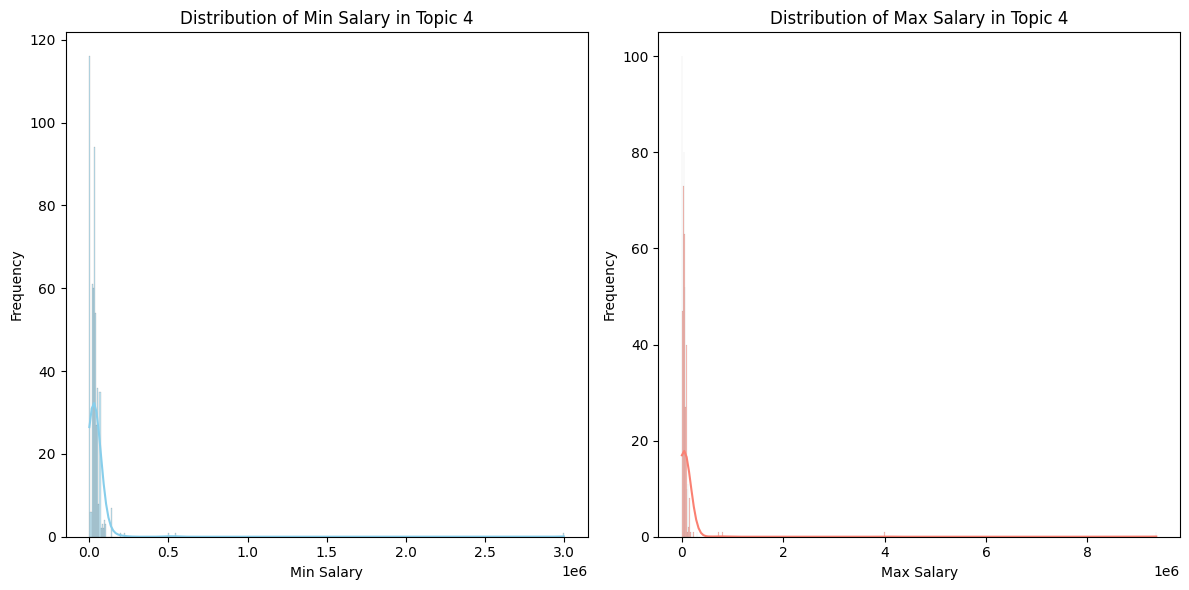

In [ ]:
import numpy as np

# Function to parse salary range
def parse_salary_range(salary_range):
    if pd.isna(salary_range):
        return np.nan, np.nan
    try:
        parts = salary_range.split('-')
        min_salary = float(parts[0].replace(',', ''))
        max_salary = float(parts[1].replace(',', ''))
        return min_salary, max_salary
    except:
        return np.nan, np.nan

# Apply the function to create min_salary and max_salary columns in the original df
df[['min_salary', 'max_salary']] = df['salary_range'].apply(lambda x: pd.Series(parse_salary_range(x)))

# Merge df_with_topics with the original df to get salary information
df_with_topics_salary = pd.merge(df_with_topics, df[['job_id', 'min_salary', 'max_salary']], left_index=True, right_index=True)

# Filter for Topic 4 postings
topic_4_df = df_with_topics_salary[df_with_topics_salary['Dominant_Topic'] == 4]

# Display some descriptive statistics for salary ranges in Topic 4
print("Descriptive statistics for salaries in Topic 4:")
display(topic_4_df[['min_salary', 'max_salary']].describe())

# Visualize the distribution of min_salary and max_salary for Topic 4
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(topic_4_df['min_salary'].dropna(), kde=True, color='skyblue')
plt.title('Distribution of Min Salary in Topic 4')
plt.xlabel('Min Salary')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(topic_4_df['max_salary'].dropna(), kde=True, color='salmon')
plt.title('Distribution of Max Salary in Topic 4')
plt.xlabel('Max Salary')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Correlación entre el Tópico Dominante y la Etiqueta de Fraude: 0.1331

Tasa de fraude por Tópico Dominante:


,fraudulent
Dominant_Topic,
4,0.126599
1,0.060538
0,0.022155
2,0.008097
3,0.002712


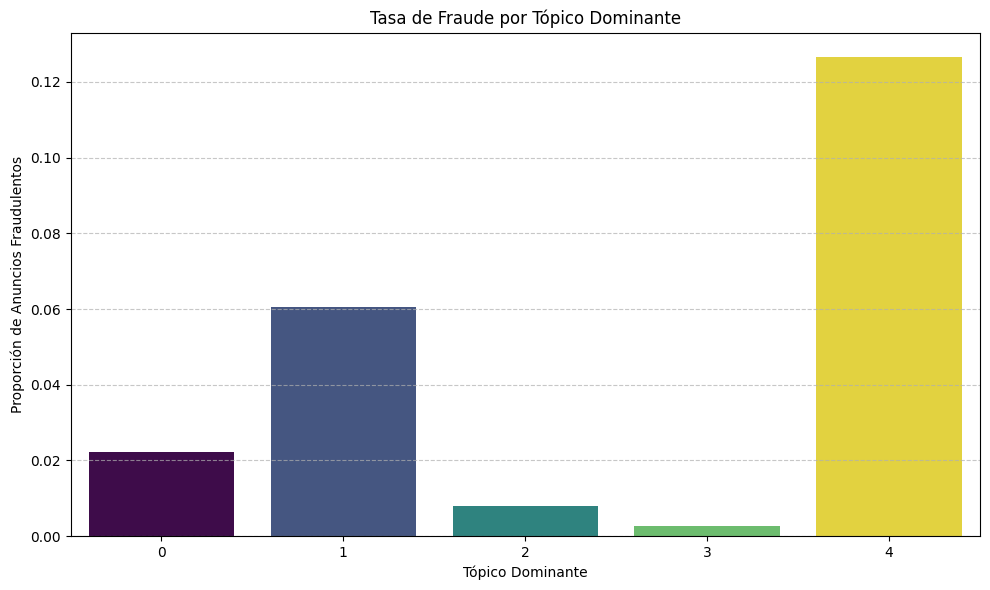

In [ ]:
# Añadir la columna 'fraudulent' al DataFrame de tópicos para el análisis
df_with_topics = df_topic_sents_keywords.copy()
df_with_topics['fraudulent'] = df['fraudulent']

# Calcular la correlación entre el tópico dominante y la etiqueta de fraude
# Convertimos 'Dominant_Topic' a tipo numérico si no lo es ya.
# Usaremos Pearson correlation, que es adecuada si ambos son numéricos.
# Si Dominant_Topic es categórico ordinal, podemos tratarlo como numérico para la correlación lineal.
correlation_dominant_topic_fraud = df_with_topics['Dominant_Topic'].corr(df_with_topics['fraudulent'])

print(f"Correlación entre el Tópico Dominante y la Etiqueta de Fraude: {correlation_dominant_topic_fraud:.4f}")

# Para una interpretación más detallada, podemos agrupar y ver la tasa de fraude por tópico
fraud_rate_by_topic = df_with_topics.groupby('Dominant_Topic')['fraudulent'].mean().sort_values(ascending=False)

print("\nTasa de fraude por Tópico Dominante:")
display(fraud_rate_by_topic)

# Visualizar la tasa de fraude por tópico
plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_rate_by_topic.index, y=fraud_rate_by_topic.values, hue=fraud_rate_by_topic.index, palette='viridis', legend=False)
plt.title('Tasa de Fraude por Tópico Dominante')
plt.xlabel('Tópico Dominante')
plt.ylabel('Proporción de Anuncios Fraudulentos')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Fraudulent rate by Employment Type:


,fraudulent
employment_type,
Part-time,0.092848
Other,0.066079
Full-time,0.042169
Contract,0.028871
Temporary,0.008299


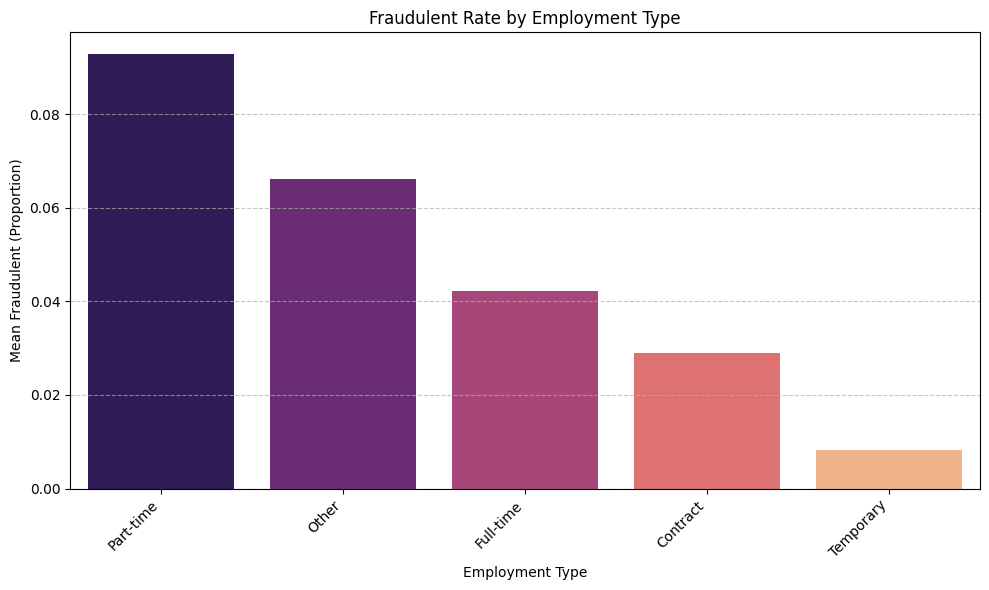

In [ ]:
# Analyze 'employment_type' vs 'fraudulent'
employment_fraud_rate = df.groupby('employment_type')['fraudulent'].mean().sort_values(ascending=False)
print("\nFraudulent rate by Employment Type:")
display(employment_fraud_rate)

plt.figure(figsize=(10, 6))
sns.barplot(x=employment_fraud_rate.index, y=employment_fraud_rate.values, hue=employment_fraud_rate.index, palette='magma', legend=False)
plt.title('Fraudulent Rate by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Mean Fraudulent (Proportion)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Fraudulent rate by Required Experience:


,fraudulent
required_experience,
Executive,0.070922
Entry level,0.066370
Not Applicable,0.053763
Director,0.043702
Mid-Senior level,0.029667
Internship,0.026247
Associate,0.018285


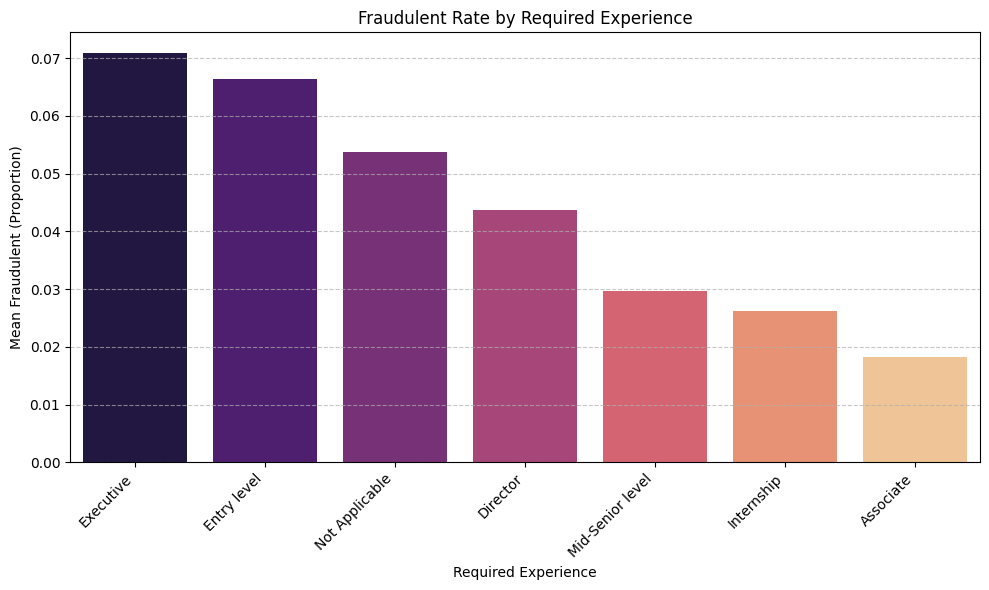

In [ ]:
# Analyze 'required_experience' vs 'fraudulent'
experience_fraud_rate = df.groupby('required_experience')['fraudulent'].mean().sort_values(ascending=False)
print("\nFraudulent rate by Required Experience:")
display(experience_fraud_rate)

plt.figure(figsize=(10, 6))
sns.barplot(x=experience_fraud_rate.index, y=experience_fraud_rate.values, hue=experience_fraud_rate.index, palette='magma', legend=False)
plt.title('Fraudulent Rate by Required Experience')
plt.xlabel('Required Experience')
plt.ylabel('Mean Fraudulent (Proportion)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()